## 1. Environment Setup & Google Drive Integration

To process the dataset efficiently, we begin by connecting the Google Colab environment to **Google Drive**. This provides access to the compressed dataset stored in the cloud.

*   **Action**: Mounts Google Drive to `/content/drive`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Dataset Extraction to Local Disk

Drive I/O can slow down deep learning data pipelines. In this step, we extract the dataset archive (`JAAD.zip`) from Google Drive directly onto **Colab's high-speed local disk** to improve file access times during frame extraction.

*   **Source Path**: Google Drive directory.
*   **Target Directory**: `/content/JAAD_local` (Colab local runtime).

In [2]:
import zipfile
import os

# Update this path to where you uploaded JAAD.zip in your Google Drive
zip_path = '/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/JAAD.zip'

# Target directory in Colab's high-speed local disk
extract_dir = '/content/JAAD_local'

print("Unzipping dataset to local Colab runtime...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Unzipped successfully!")

Unzipping dataset to local Colab runtime...
✅ Unzipped successfully!


## 3. JAAD Annotations Parsing & Dataset Preprocessing

This step executes the main pipeline to process the **Joint Attention for Autonomous Driving (JAAD)** dataset. It parses pedestrian track annotations, extracts individual bounding box crops, and generates balanced temporal frame sequences labeled with pedestrian crossing intent.

### Key Preprocessing Steps:
1.  **XML Parsing**: Reads track annotations from XML files to isolate pedestrian bounding boxes and crossing action labels.
2.  **Dataset Partitioning**: Holds out 20 videos for evaluation on unseen data, then splits the remaining videos into **Train (60%)**, **Validation (20%)**, and **Test (20%)** sets.
3.  **Frame Sampling & Cropping**: Uniformly samples sequences of `seq_len=10` frames per pedestrian, crops bounding boxes, and resizes them to standard input dimensions (`224x224`).
4.  **Label Assignment**: Computes a binary majority label (`1`: Crossing, `0`: Not Crossing) across the sequence length.

In [3]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET
import random

def parse_jaad_xml(xml_path, min_frames=1):
    if not os.path.exists(xml_path) or os.path.getsize(xml_path) == 0:
        return {}

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print(f"    ⚠️ Warning: Could not parse XML file {xml_path}: {e}")
        return {}

    ped_tracks = {}

    for track in root.findall('track'):
        label_type = track.attrib.get('label', '').lower()
        if label_type in ['pedestrian', 'ped', 'people']:
            ped_id = track.attrib.get('id', '')
            frames = {}

            for box in track.findall('box'):
                frame_idx = int(box.attrib['frame'])
                xtl = float(box.attrib['xtl'])
                ytl = float(box.attrib['ytl'])
                xbr = float(box.attrib['xbr'])
                ybr = float(box.attrib['ybr'])

                crossing = 0
                for attribute in box.findall('attribute'):
                    attr_name = attribute.attrib.get('name', '').lower()
                    attr_val = attribute.text.lower() if attribute.text else ''
                    if attr_name == 'action' or 'cross' in attr_name:
                        if attr_val in ['crossing', '1', 'true', 'yes']:
                            crossing = 1

                frames[frame_idx] = {
                    'bbox': [xtl, ytl, xbr, ybr],
                    'crossing': crossing
                }

            if len(frames) >= min_frames:
                ped_tracks[ped_id] = frames

    return ped_tracks

def process_and_crop_jaad_with_split(jaad_path, output_dir, target_size=(224, 224), seq_len=10, seed=42, num_new_data_vids=20):
    clips_dir = os.path.join(jaad_path, 'JAAD_clips')
    annotations_dir = os.path.join(jaad_path, 'annotations')

    if not os.path.exists(clips_dir):
        clips_dir = jaad_path

    # Added 'new_data' to splits
    splits = ['train', 'val', 'test', 'new_data']
    labels = ['crossing', 'not_crossing']

    for split in splits:
        for label in labels:
            os.makedirs(os.path.join(output_dir, split, label), exist_ok=True)

    video_files = sorted([f for f in os.listdir(clips_dir) if f.endswith('.mp4')])
    total_videos = len(video_files)

    # -------------------------------------------------------------
    # Reserve 20 Videos for "New Data", then 60/20/20 Split on Remaining
    # -------------------------------------------------------------
    random.seed(seed)
    shuffled_videos = video_files.copy()
    random.shuffle(shuffled_videos)

    # 1. Isolate the 20 new data videos
    new_data_vids = set(shuffled_videos[:num_new_data_vids])
    remaining_vids = shuffled_videos[num_new_data_vids:]
    num_remaining = len(remaining_vids)

    # 2. Compute 60/20/20 on the remaining videos
    train_end = int(0.60 * num_remaining)
    val_end = int(0.80 * num_remaining)

    train_vids = set(remaining_vids[:train_end])
    val_vids = set(remaining_vids[train_end:val_end])
    test_vids = set(remaining_vids[val_end:])

    print("=" * 60)
    print(f"🚀 [START] Processing {total_videos} total videos")
    print(f"📌 Video Allocations:")
    print(f"   - Held-out New Data: {len(new_data_vids)} videos")
    print(f"   - Train (60%):       {len(train_vids)} videos")
    print(f"   - Val   (20%):       {len(val_vids)} videos")
    print(f"   - Test  (20%):       {len(test_vids)} videos")
    print(f"📁 [OUTPUT TARGET] {output_dir}")
    print("=" * 60 + "\n")

    # Track sequence counts including 'new_data'
    sequence_counts = {'train': 0, 'val': 0, 'test': 0, 'new_data': 0}

    for i, video_name in enumerate(video_files, 1):
        video_id = video_name.split('.')[0]
        video_path = os.path.join(clips_dir, video_name)
        xml_path = os.path.join(annotations_dir, f"{video_id}.xml")

        # Assign video to designated split
        if video_name in new_data_vids:
            target_split = 'new_data'
        elif video_name in train_vids:
            target_split = 'train'
        elif video_name in val_vids:
            target_split = 'val'
        else:
            target_split = 'test'

        print(f"[{i}/{total_videos}] 🎬 Processing: {video_name} -> Assigning to [{target_split.upper()}]...")

        if not os.path.exists(xml_path):
            print(f"    ⏩ [SKIP] XML missing: {xml_path}")
            continue

        ped_tracks = parse_jaad_xml(xml_path, min_frames=1)
        if not ped_tracks:
            print(f"    ⏩ [SKIP] No pedestrian tracks found in {video_name}")
            continue

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"    ❌ [ERROR] Could not open video: {video_path}")
            continue

        for ped_id, frame_data in ped_tracks.items():
            sorted_frames = sorted(frame_data.keys())

            if len(sorted_frames) < seq_len:
                sampled_frame_keys = np.random.choice(sorted_frames, seq_len, replace=True)
                sampled_frame_keys = sorted(sampled_frame_keys)
            else:
                sample_indices = np.linspace(0, len(sorted_frames) - 1, seq_len, dtype=int)
                sampled_frame_keys = [sorted_frames[idx] for idx in sample_indices]

            cropped_sequence = []
            crossing_labels = []

            for f_idx in sampled_frame_keys:
                cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
                ret, frame = cap.read()
                if not ret:
                    break

                h, w, _ = frame.shape
                bbox = frame_data[f_idx]['bbox']
                crossing = frame_data[f_idx]['crossing']

                x1, y1 = max(0, int(bbox[0])), max(0, int(bbox[1]))
                x2, y2 = min(w, int(bbox[2])), min(h, int(bbox[3]))

                crop = frame[y1:y2, x1:x2]
                if crop.size == 0:
                    break

                crop_resized = cv2.resize(crop, target_size)
                cropped_sequence.append(crop_resized)
                crossing_labels.append(crossing)

            # Only save if we successfully extracted the full sequence
            if len(cropped_sequence) == seq_len:
                final_label = 1 if (sum(crossing_labels) / seq_len) >= 0.5 else 0
                label_str = 'crossing' if final_label == 1 else 'not_crossing'

                seq_folder = os.path.join(output_dir, target_split, label_str, f"{video_id}_{ped_id}")
                os.makedirs(seq_folder, exist_ok=True)

                for frame_idx, img in enumerate(cropped_sequence):
                    img_path = os.path.join(seq_folder, f"frame_{frame_idx:02d}.jpg")
                    cv2.imwrite(img_path, img)

                sequence_counts[target_split] += 1

        cap.release()

        if i % 20 == 0 or i == total_videos:
            tot_samples = sum(sequence_counts.values())
            print(f"    ✔️ Progress: {i}/{total_videos} videos done | Total sequences saved: {tot_samples}")

    print("\n" + "=" * 60)
    print("💾 Summary of Extracted Image Sequences Saved to Disk:")
    print(f"   - Train Sequences:    {sequence_counts['train']}")
    print(f"   - Val Sequences:      {sequence_counts['val']}")
    print(f"   - Test Sequences:     {sequence_counts['test']}")
    print(f"   - New Data Sequences: {sequence_counts['new_data']}")
    print(f"\n🎉 [DONE] Pre-split image dataset saved at: {output_dir}")
    print("=" * 60)

# Run process
process_and_crop_jaad_with_split(
    jaad_path='/content/JAAD_local/JAAD',
    output_dir='/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Processed_JAAD_Dataset_Images',
    seed=42,
    num_new_data_vids=20
)

🚀 [START] Processing 346 total videos
📌 Video Allocations:
   - Held-out New Data: 20 videos
   - Train (60%):       195 videos
   - Val   (20%):       65 videos
   - Test  (20%):       66 videos
📁 [OUTPUT TARGET] /content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Processed_JAAD_Dataset_Images

[1/346] 🎬 Processing: video_0001.mp4 -> Assigning to [TRAIN]...
[2/346] 🎬 Processing: video_0002.mp4 -> Assigning to [TRAIN]...
[3/346] 🎬 Processing: video_0003.mp4 -> Assigning to [TRAIN]...
[4/346] 🎬 Processing: video_0004.mp4 -> Assigning to [TEST]...
[5/346] 🎬 Processing: video_0005.mp4 -> Assigning to [TRAIN]...
[6/346] 🎬 Processing: video_0006.mp4 -> Assigning to [TRAIN]...
[7/346] 🎬 Processing: video_0007.mp4 -> Assigning to [TRAIN]...
[8/346] 🎬 Processing: video_0008.mp4 -> Assigning to [TRAIN]...
[9/346] 🎬 Processing: video_0009.mp4 -> Assigning to [TRAIN]...
[10/346] 🎬 Processing: video_0010.mp4 -> Assigning to [TRAIN]...
[11/346] 🎬 Processing: video_0011.mp4 -> Assigning to [

## 4. Visualizing Preprocessed Sequences

To verify that frame crops, temporal sequence ordering, and binary label assignments were executed correctly, this section loads and visualizes an extracted pedestrian sequence inline.

*   **Target Split**: `train`
*   **Sequence Displayed**: 10-frame bounding-box crops resized for deep learning feature extraction.


🎬 VISUALIZING SAMPLE SEQUENCE: video_0066_
 - Total Frames Loaded: 10
 - Label: CROSSING



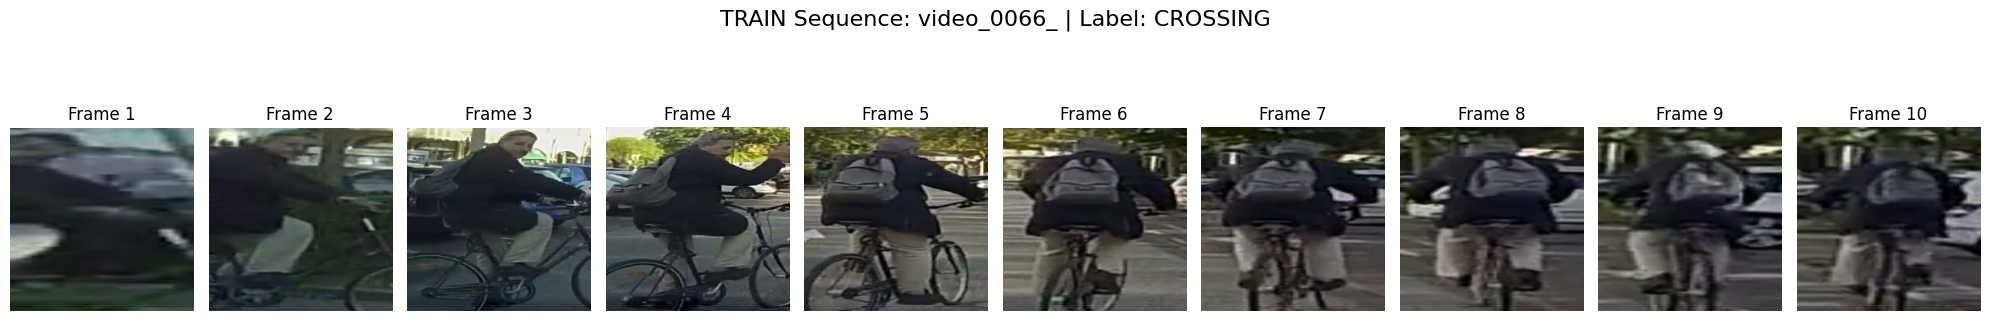

In [4]:
import os
import cv2
import matplotlib.pyplot as plt

# Path to your preprocessed image dataset directory
dataset_dir = '/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Processed_JAAD_Dataset_Images'

target_split = 'train'  # Options: 'train', 'val', 'test'

# 1. Print dataset split statistics (sequence counts)
split_sequences = {}
for split in ['train', 'val', 'test']:
    split_sequences[split] = []
    for label in ['crossing', 'not_crossing']:
        label_dir = os.path.join(dataset_dir, split, label)
        if os.path.exists(label_dir):
            for seq_folder in os.listdir(label_dir):
                full_seq_path = os.path.join(label_dir, seq_folder)
                if os.path.isdir(full_seq_path):
                    split_sequences[split].append((full_seq_path, label))

# 2. Pick the first sequence from the chosen split
if not split_sequences[target_split]:
    raise FileNotFoundError(f"No sequence folders found under split '{target_split}' in {dataset_dir}")

first_seq_path, label_str = split_sequences[target_split][14]
seq_folder_name = os.path.basename(first_seq_path)

# Load all frame images from the sequence folder in sorted order
frame_files = sorted([f for f in os.listdir(first_seq_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

print("\n" + "=" * 50)
print(f"🎬 VISUALIZING SAMPLE SEQUENCE: {seq_folder_name}")
print(f" - Total Frames Loaded: {len(frame_files)}")
print(f" - Label: {label_str.upper()}")
print("=" * 50 + "\n")

# 3. Plotting all frames inline
num_frames = len(frame_files)
fig, axes = plt.subplots(1, num_frames, figsize=(20, 4))
fig.suptitle(f"{target_split.upper()} Sequence: {seq_folder_name} | Label: {label_str.upper()}", fontsize=16)

# Handle single frame edge case (ensures axes is iterable)
if num_frames == 1:
    axes = [axes]

for i, img_name in enumerate(frame_files):
    img_path = os.path.join(first_seq_path, img_name)
    frame_bgr = cv2.imread(img_path)

    if frame_bgr is None:
        print(f"⚠️ Warning: Could not load image at {img_path}")
        continue

    # Convert BGR (OpenCV) to RGB (matplotlib)
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    axes[i].imshow(frame_rgb)
    axes[i].set_title(f"Frame {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

---
## 5. Dataset Statistics & Class Distribution

We analyze the extracted sequences to confirm sample counts across train, validation, and test splits, and inspect the binary class balance between crossing ($1$) and non-crossing ($0$) intent targets.

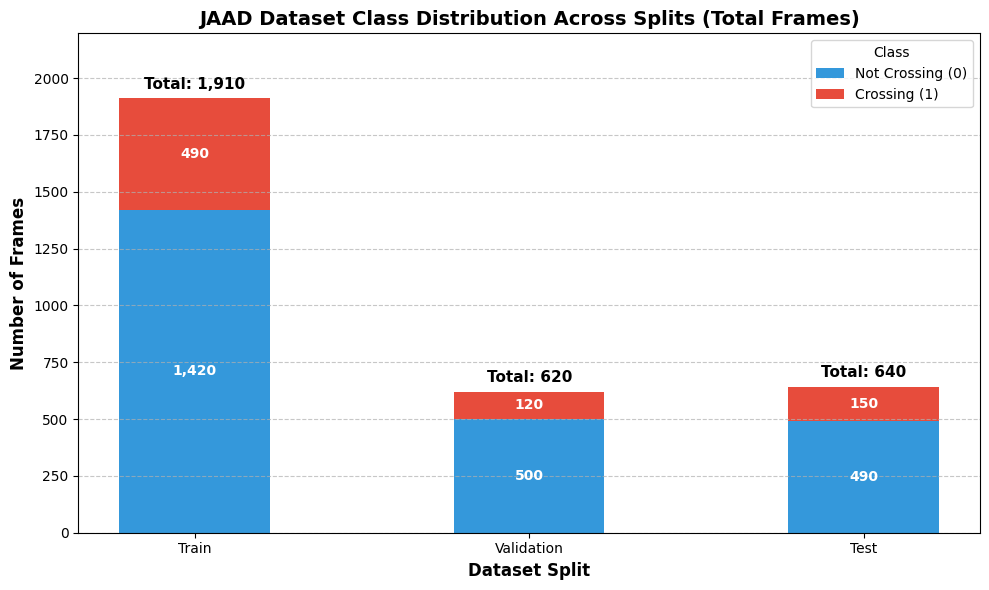

In [5]:
import os
import matplotlib.pyplot as plt

# Update this path to match your preprocessed image directory
dataset_dir = '/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Processed_JAAD_Dataset_Images'

splits = ['train', 'val', 'test']
classes = ['not_crossing', 'crossing']

# Initialize stats structure
frame_stats = {
    'train': {'not_crossing': 0, 'crossing': 0},
    'val':   {'not_crossing': 0, 'crossing': 0},
    'test':  {'not_crossing': 0, 'crossing': 0}
}

# Count frame files dynamically from the filesystem
for split in splits:
    for cls in classes:
        cls_dir = os.path.join(dataset_dir, split, cls)

        if not os.path.exists(cls_dir):
            continue

        # Walk through sequence folders inside each split/class directory
        for root, _, files in os.walk(cls_dir):
            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    frame_stats[split][cls] += 1

# Extract values for plotting
split_labels = ['Train', 'Validation', 'Test']
not_crossing_frames = [frame_stats[s]['not_crossing'] for s in splits]
crossing_frames = [frame_stats[s]['crossing'] for s in splits]

# Plotting configuration
x = list(range(len(split_labels)))
width = 0.45

plt.figure(figsize=(10, 6))

# Stacked bars creation
bars1 = plt.bar(x, not_crossing_frames, width, label='Not Crossing (0)', color='#3498db')
bars2 = plt.bar(x, crossing_frames, width, bottom=not_crossing_frames, label='Crossing (1)', color='#e74c3c')

# Formatting labels and headers
plt.xlabel('Dataset Split', fontsize=12, fontweight='bold')
plt.ylabel('Number of Frames', fontsize=12, fontweight='bold')
plt.title('JAAD Dataset Class Distribution Across Splits (Total Frames)', fontsize=14, fontweight='bold')
plt.xticks(x, split_labels)
plt.legend(title='Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate individual class counts inside/on the stacked segments
for b1, b2 in zip(bars1, bars2):
    h1 = b1.get_height()
    h2 = b2.get_height()

    # Label bottom segment (Not Crossing)
    if h1 > 0:
        plt.annotate(f'{h1:,}',
                     xy=(b1.get_x() + b1.get_width() / 2, h1 / 2),
                     ha='center', va='center', color='white', fontweight='bold')

    # Label top segment (Crossing)
    if h2 > 0:
        plt.annotate(f'{h2:,}',
                     xy=(b2.get_x() + b2.get_width() / 2, h1 + (h2 / 2)),
                     ha='center', va='center', color='white', fontweight='bold')

    # Annotate TOTAL count above the top of the stack
    total = h1 + h2
    plt.annotate(f'Total: {total:,}',
                 xy=(b1.get_x() + b1.get_width() / 2, total),
                 xytext=(0, 5),
                 textcoords="offset points",
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add padding to top of y-axis to comfortably fit top total labels
plt.ylim(0, max([nc + c for nc, c in zip(not_crossing_frames, crossing_frames)]) * 1.15)

plt.tight_layout()
plt.show()

---
## 6. Baseline Model Training: 2D Spatial CNN

To establish a benchmark for our temporal sequence model, we construct a lightweight **2D Convolutional Neural Network (CNN)**.

### 📐 Baseline Model Overview:
* **Architecture:** 2 Convolutional blocks (Conv2D + BatchNorm + ReLU + MaxPool) followed by a Dense FC classifier with 50% Dropout.
* **Input Strategy:** Single-frame evaluation using only the **final frame** ($t_{10}$) of each sequence resized to $224 \times 224 \times 3$.
* **Optimization:** Binary Cross-Entropy Loss (`BCEWithLogitsLoss`) trained via Adam ($LR = 0.01$) over 20 epochs.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Starting training baseline model for 20 epochs...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/20 | Train Loss: 90.3111, Train Acc: 58.12% | Val Loss: 17.0234, Val Acc: 40.32% (Saved Best Model)
Epoch 02/20 | Train Loss: 86.5992, Train Acc: 55.50% | Val Loss: 16.5514, Val Acc: 80.65% (Saved Best Model)
Epoch 03/20 | Train Loss: 36.2806, Train Acc: 68.59% | Val Loss: 5.5126, Val Acc: 69.35% (Saved Best Model)
Epoch 04/20 | Train Loss: 11.0541, Train Acc: 69.11% | Val Loss: 5.5944, Val Acc: 79.03%
Epoch 05/20 | Train Loss: 5.1566, Train Acc: 57.07% | Val Loss: 2.0709, Val Acc: 80.65% (Saved Best Model)
Epoch 06/20 | Train Loss: 3.2395, Train Acc: 66.49% | Val Loss: 1.4793, Val Acc: 79.03% (Saved Best Model)
Epoch 07/20 | Train Loss: 2.0750, Train Acc: 69.11% | Val Loss: 0.7653, Val Acc: 51.61% (Saved Best Model)
Epoch 08/20 | Train Loss: 1.5110, Train Acc: 66.49% | Val Loss: 0.7101, Val Acc: 80.65% (Saved Best Model)
Epoch 09/20 | Train Loss: 0.8642, Train Acc: 72.25% | Val Loss: 2.4531, Val Acc: 80.65%
Epoch 10/20 | Train Loss: 1.2884, Train Acc: 61.26% | Val Loss: 0.984

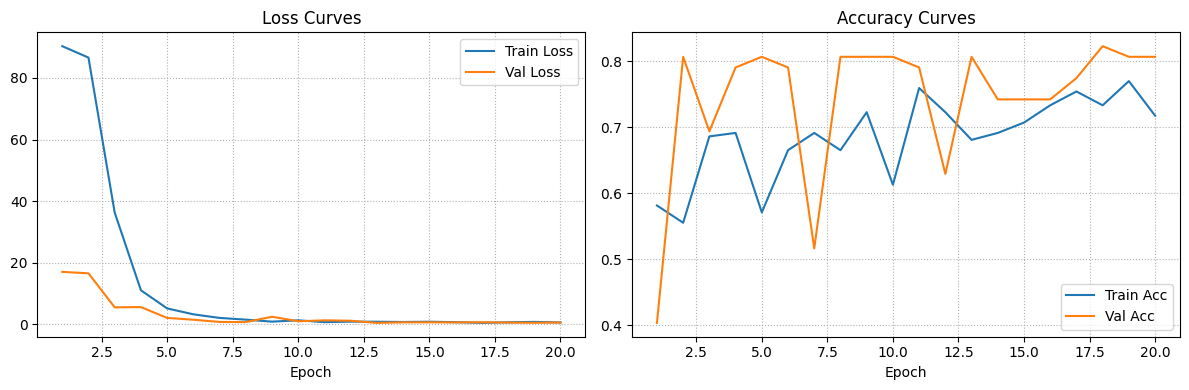

In [6]:
import os
import random
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 0. Google Drive Mount & Configuration
# -------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Processed_JAAD_Dataset_Images"
IMG_SIZE = 224
SEQ_LEN = 10
BATCH_SIZE = 32
EPOCHS = 20
LR = 0.01

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# -------------------------------------------------------------
# 1. Dataset Handling Reading Directly from Image Directories
# -------------------------------------------------------------
class JAADImageBaselineDataset(Dataset):
    def __init__(self, data_dir: str, split: str, train: bool, img_size: int = 224, seq_len: int = 10):
        self.split_dir = os.path.join(data_dir, split)
        self.train = train
        self.img_size = img_size
        self.seq_len = seq_len
        self.samples = []

        if not os.path.exists(self.split_dir):
            raise ValueError(f"Split directory '{self.split_dir}' does not exist.")

        for label_str in ['crossing', 'not_crossing']:
            label_val = 1.0 if label_str == 'crossing' else 0.0
            class_dir = os.path.join(self.split_dir, label_str)

            if not os.path.exists(class_dir):
                continue

            for seq_folder in os.listdir(class_dir):
                seq_path = os.path.join(class_dir, seq_folder)
                if os.path.isdir(seq_path):
                    frames = sorted([f for f in os.listdir(seq_path) if f.endswith(('.jpg', '.png', '.jpeg'))])

                    if len(frames) == 0:
                        continue

                    if len(frames) >= self.seq_len:
                        indices = np.linspace(0, len(frames) - 1, self.seq_len).astype(int)
                        selected_frames = [frames[i] for i in indices]
                    else:
                        selected_frames = frames + [frames[-1]] * (self.seq_len - len(frames))

                    frame_paths = [os.path.join(seq_path, f) for f in selected_frames]
                    self.samples.append({
                        "frame_paths": frame_paths,
                        "label": label_val
                    })

        if len(self.samples) == 0:
            raise ValueError(f"No valid sequences found in {self.split_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        frame_paths = sample["frame_paths"]
        label = sample["label"]

        # Select the final frame path for the 2D baseline
        final_frame_path = frame_paths[-1]

        # Read image using OpenCV
        img_bgr = cv2.imread(final_frame_path)
        if img_bgr is None:
            img_bgr = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Convert to Tensor [C, H, W] normalized to [0, 1]
        image_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0

        if image_tensor.shape[1] != self.img_size or image_tensor.shape[2] != self.img_size:
            image_tensor = TF.resize(image_tensor, [self.img_size, self.img_size], antialias=True)

        # Apply spatial data augmentations during training
        if self.train:
            if random.random() < 0.5:
                image_tensor = TF.hflip(image_tensor)

            brightness = random.uniform(0.8, 1.2)
            contrast = random.uniform(0.8, 1.2)
            saturation = random.uniform(0.8, 1.2)

            image_tensor = TF.adjust_brightness(image_tensor, brightness)
            image_tensor = TF.adjust_contrast(image_tensor, contrast)
            image_tensor = TF.adjust_saturation(image_tensor, saturation)

        return image_tensor, torch.tensor(label)


# Instantiate Datasets and DataLoaders
train_dataset = JAADImageBaselineDataset(DATA_DIR, split='train', train=True, img_size=IMG_SIZE, seq_len=SEQ_LEN)
val_dataset = JAADImageBaselineDataset(DATA_DIR, split='val', train=False, img_size=IMG_SIZE, seq_len=SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


# -------------------------------------------------------------
# 2. Simple Baseline CNN Model (UNCHANGED)
# -------------------------------------------------------------
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# -------------------------------------------------------------
# 3. Model Configuration & Instantiation
# -------------------------------------------------------------
model = BaselineCNN()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# History structure matching the final model's metrics
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss = float('inf')


# -------------------------------------------------------------
# 4. Integrated Training Loop
# -------------------------------------------------------------
print(f"\nStarting training baseline model for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    # Training Phase
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = (outputs >= 0.0).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to(device)
            val_labels = val_labels.to(device).float().unsqueeze(1)

            val_outputs = model(val_inputs)
            v_loss = criterion(val_outputs, val_labels)

            val_loss += v_loss.item() * val_inputs.size(0)
            val_preds = (val_outputs >= 0.0).float()
            val_correct += (val_preds == val_labels).sum().item()
            val_total += val_labels.size(0)

    valid_loss = val_loss / val_total
    valid_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(valid_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(valid_acc)

    saved_str = ""
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), 'best_baseline_model.pth')
        saved_str = " (Saved Best Model)"

    # Print summary format identical to the final model
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {valid_loss:.4f}, Val Acc: {valid_acc*100:.2f}%{saved_str}")

print(f"\nTraining finished. Best validation loss encountered: {best_val_loss:.4f}")


# -------------------------------------------------------------
# 5. Graph Generation (Matched to Final Model Layout)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

# Loss Plot
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, linestyle=":")

# Accuracy Plot
axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, linestyle=":")

plt.tight_layout()
plt.savefig('baseline_training_curves.png', dpi=300)
plt.show()

---
## 7. Primary Model Architecture: MobileNetV3 + Bidirectional GRU + Temporal Attention

We implement a spatio-temporal deep neural network designed to capture dynamic pedestrian behavioral cues across continuous video sequences.

### 🏗️ Architectural Pipeline:
1. **Spatial Feature Extractor:** Pretrained **MobileNetV3-Small** backbone (fine-tuned with differential learning rates) extracting 1D feature embeddings per frame.
2. **Temporal Sequential Encoder:** 2-layer **Bidirectional GRU** ($\text{hidden\_dim} = 128$) capturing forward and backward motion trajectories across sequence steps.
3. **Spatio-Temporal Attention Mechanism:** Learnable scalar temporal attention weights dynamically emphasizing key transition frames.
4. **Classification Head:** Dense layer with Batch Normalization, ReLU activation, 50% Dropout regularization, and single-logit output.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 64.5MB/s]


🔒 MobileNetV3 backbone frozen for initial 5 warmup epochs.

Starting training with Differential LR (Backbone: 1e-05, Head: 0.0003)...

Epoch 01/35 | Train Loss: 1.1122, Train Acc: 69.89% | Val Loss: 0.9095, Val Acc: 75.81% (Saved Best Model)
Epoch 02/35 | Train Loss: 1.1921, Train Acc: 72.73% | Val Loss: 0.8549, Val Acc: 69.35%
Epoch 03/35 | Train Loss: 0.8664, Train Acc: 75.57% | Val Loss: 0.7636, Val Acc: 74.19%
Epoch 04/35 | Train Loss: 0.7375, Train Acc: 85.80% | Val Loss: 0.6392, Val Acc: 80.65% (Saved Best Model)
Epoch 05/35 | Train Loss: 0.7890, Train Acc: 86.36% | Val Loss: 0.6041, Val Acc: 79.03%
🔓 Epoch 06: Unfreezing MobileNetV3 backbone for fine-tuning!
Epoch 06/35 | Train Loss: 0.7706, Train Acc: 88.07% | Val Loss: 0.5522, Val Acc: 82.26% (Saved Best Model)
Epoch 07/35 | Train Loss: 0.6391, Train Acc: 91.48% | Val Loss: 0.5507, Val Acc: 80.65%
Epoch 08/35 | Train Loss: 0.6151, Train Acc: 89.20% | Val Loss: 0.5474, Val Acc: 83.87% (Saved Best Model)
Epoch 09/35 | Train Loss

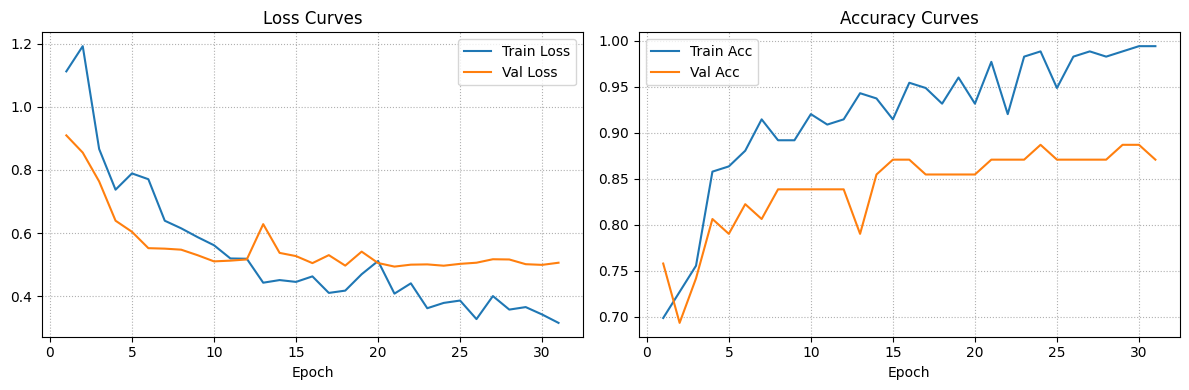

In [7]:
import os
import json
import random
from dataclasses import dataclass, asdict
import cv2

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TF
import torchvision.models as models
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
)

# --------------------------------------------------------------------------
# 0. Google Drive Mount
# --------------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')


# --------------------------------------------------------------------------
# 1. Reproducibility & Config
# --------------------------------------------------------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


@dataclass
class TrainConfig:
    data_dir: str = "/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Processed_JAAD_Dataset_Images"
    output_dir: str = "/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Runs/run_mobilenet_gru"
    seq_len: int = 10
    img_size: int = 224
    batch_size: int = 16
    epochs: int = 35
    freeze_backbone_epochs: int = 5      # Freeze MobileNetV3 for initial epochs
    backbone_lr: float = 1e-5            # Smaller LR for pretrained backbone
    head_lr: float = 3e-4                # Standard LR for GRU & classifier
    weight_decay: float = 1e-2           # Increased weight decay for regularization
    hidden_dim: int = 128
    classifier_dropout: float = 0.5      # Increased dropout
    grad_clip_norm: float = 1.0
    early_stop_patience: int = 7         # Early stopping patience
    label_smoothing: float = 0.05        # Soften binary labels
    num_workers: int = 2
    seed: int = 42
    use_amp: bool = True
    use_weighted_sampler: bool = True
    use_pos_weight: bool = True


# --------------------------------------------------------------------------
# 2. Dataset Definition with Enhanced Augmentation
# --------------------------------------------------------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class JAADImageDataset(Dataset):
    def __init__(self, data_dir: str, split: str, train: bool, img_size: int = 224, seq_len: int = 10):
        self.split_dir = os.path.join(data_dir, split)
        self.train = train
        self.img_size = img_size
        self.seq_len = seq_len
        self.samples = []

        if not os.path.exists(self.split_dir):
            raise ValueError(f"Split directory '{self.split_dir}' does not exist.")

        for label_str in ['crossing', 'not_crossing']:
            label_val = 1.0 if label_str == 'crossing' else 0.0
            class_dir = os.path.join(self.split_dir, label_str)

            if not os.path.exists(class_dir):
                continue

            for seq_folder in os.listdir(class_dir):
                seq_path = os.path.join(class_dir, seq_folder)
                if os.path.isdir(seq_path):
                    frames = sorted([f for f in os.listdir(seq_path) if f.endswith(('.jpg', '.png', '.jpeg'))])

                    if len(frames) == 0:
                        continue

                    if len(frames) >= self.seq_len:
                        indices = np.linspace(0, len(frames) - 1, self.seq_len).astype(int)
                        selected_frames = [frames[i] for i in indices]
                    else:
                        selected_frames = frames + [frames[-1]] * (self.seq_len - len(frames))

                    frame_paths = [os.path.join(seq_path, f) for f in selected_frames]
                    self.samples.append({
                        "frame_paths": frame_paths,
                        "label": label_val
                    })

        if len(self.samples) == 0:
            raise ValueError(f"No valid sequences found in {self.split_dir}")

    def __len__(self):
        return len(self.samples)

    def labels(self):
        return [s["label"] for s in self.samples]

    def __getitem__(self, idx):
        sample = self.samples[idx]
        frame_paths = sample["frame_paths"]
        label = sample["label"]

        # Shared augmentations across the entire frame sequence for temporal consistency
        do_flip = self.train and random.random() < 0.5
        rot_angle = random.uniform(-10.0, 10.0) if self.train else 0.0
        brightness = random.uniform(0.8, 1.2) if self.train else 1.0
        contrast = random.uniform(0.8, 1.2) if self.train else 1.0
        saturation = random.uniform(0.8, 1.2) if self.train else 1.0

        frames = []
        for path in frame_paths:
            img_bgr = cv2.imread(path)
            if img_bgr is None:
                img_bgr = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0

            if tensor.shape[1] != self.img_size or tensor.shape[2] != self.img_size:
                tensor = TF.resize(tensor, [self.img_size, self.img_size], antialias=True)

            if self.train:
                if do_flip:
                    tensor = TF.hflip(tensor)
                if abs(rot_angle) > 0.1:
                    tensor = TF.rotate(tensor, angle=rot_angle)
                tensor = TF.adjust_brightness(tensor, brightness)
                tensor = TF.adjust_contrast(tensor, contrast)
                tensor = TF.adjust_saturation(tensor, saturation)

            tensor = TF.normalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
            frames.append(tensor)

        sequence_tensor = torch.stack(frames, dim=0)  # (T, 3, H, W)
        return sequence_tensor, torch.tensor(label)


# --------------------------------------------------------------------------
# 3. Enhanced Architecture
# --------------------------------------------------------------------------
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, max(hidden_dim // 2, 1)),
            nn.Tanh(),
            nn.Linear(max(hidden_dim // 2, 1), 1),
        )

    def forward(self, rnn_out):
        scores = self.attn(rnn_out)               # (N, T, 1)
        weights = torch.softmax(scores, dim=1)     # (N, T, 1)
        context = (rnn_out * weights).sum(dim=1)  # (N, hidden_dim)
        return context


class CrossingMobileNetGRU(nn.Module):
    def __init__(self, hidden_dim=128, classifier_dropout=0.5):
        super().__init__()
        mobilenet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        in_features = mobilenet.classifier[0].in_features
        mobilenet.classifier = nn.Identity()
        self.backbone = mobilenet

        self.gru = nn.GRU(
            input_size=in_features,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        rnn_out_dim = hidden_dim * 2

        self.attention = TemporalAttention(rnn_out_dim)

        self.classifier = nn.Sequential(
            nn.Linear(rnn_out_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(classifier_dropout),
            nn.Linear(64, 1)
        )

    def freeze_backbone(self, freeze: bool = True):
        for param in self.backbone.parameters():
            param.requires_grad = not freeze

    def forward(self, x):
        n, t, c, h, w = x.shape
        x = x.view(n * t, c, h, w)
        feats = self.backbone(x)            # (N*T, in_features)
        feats = feats.view(n, t, -1)        # (N, T, in_features)

        rnn_out, _ = self.gru(feats)        # (N, T, hidden_dim * 2)
        context = self.attention(rnn_out)   # (N, hidden_dim * 2)

        logits = self.classifier(context)   # (N, 1)
        return logits


# --------------------------------------------------------------------------
# 4. Helpers & Engine
# --------------------------------------------------------------------------
def make_weighted_sampler(labels):
    labels = np.array(labels)
    class_counts = np.bincount(labels.astype(int), minlength=2)
    class_weights = 1.0 / np.clip(class_counts, 1, None)
    sample_weights = class_weights[labels.astype(int)]
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )
    return sampler, class_counts


def compute_metrics(y_true, y_probs, threshold=0.5):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    preds = (y_probs >= threshold).astype(int)

    acc = accuracy_score(y_true, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, preds, average="binary", zero_division=0
    )
    try:
        auc = roc_auc_score(y_true, y_probs)
    except ValueError:
        auc = float("nan")
    try:
        pr_auc = average_precision_score(y_true, y_probs)
    except ValueError:
        pr_auc = float("nan")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc,
        "pr_auc": pr_auc,
    }


def run_epoch(model, loader, device, criterion, optimizer=None, scaler=None, use_amp=True, label_smoothing=0.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, n_samples = 0.0, 0
    all_probs, all_labels = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).float().unsqueeze(1)

            if is_train:
                optimizer.zero_grad()

            with torch.amp.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
                logits = model(inputs)

                # Apply label smoothing during training to prevent overconfidence
                if is_train and label_smoothing > 0.0:
                    smoothed_labels = labels * (1.0 - label_smoothing) + 0.5 * label_smoothing
                    loss = criterion(logits, smoothed_labels)
                else:
                    loss = criterion(logits, labels)

            if is_train:
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            n_samples += inputs.size(0)
            probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.detach().cpu().numpy().flatten().tolist())

    avg_loss = total_loss / max(n_samples, 1)
    return avg_loss, all_labels, all_probs


# --------------------------------------------------------------------------
# 5. Training Loop
# --------------------------------------------------------------------------
config = TrainConfig()
seed_everything(config.seed)
os.makedirs(config.output_dir, exist_ok=True)

train_ds = JAADImageDataset(config.data_dir, "train", train=True, img_size=config.img_size, seq_len=config.seq_len)
val_ds = JAADImageDataset(config.data_dir, "val", train=False, img_size=config.img_size, seq_len=config.seq_len)

train_labels = train_ds.labels()
sampler, class_counts = make_weighted_sampler(train_labels)

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

train_loader = DataLoader(
    train_ds, batch_size=config.batch_size,
    sampler=sampler if config.use_weighted_sampler else None,
    shuffle=False if config.use_weighted_sampler else True,
    num_workers=config.num_workers, pin_memory=use_cuda, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=config.batch_size, shuffle=False,
    num_workers=config.num_workers, pin_memory=use_cuda
)

model = CrossingMobileNetGRU(
    hidden_dim=config.hidden_dim,
    classifier_dropout=config.classifier_dropout
).to(device)

# Set initial backbone freezing state
if config.freeze_backbone_epochs > 0:
    model.freeze_backbone(True)
    print(f"🔒 MobileNetV3 backbone frozen for initial {config.freeze_backbone_epochs} warmup epochs.")

# Differential learning rates for backbone vs temporal classifier
optimizer = optim.AdamW([
    {"params": model.backbone.parameters(), "lr": config.backbone_lr},
    {"params": model.gru.parameters(), "lr": config.head_lr},
    {"params": model.attention.parameters(), "lr": config.head_lr},
    {"params": model.classifier.parameters(), "lr": config.head_lr},
], weight_decay=config.weight_decay)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs, eta_min=1e-6)
scaler = torch.amp.GradScaler(enabled=config.use_amp and device.type == "cuda")

n_pos = max((np.array(train_labels) == 1).sum(), 1)
n_neg = max((np.array(train_labels) == 0).sum(), 1)
pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device) if config.use_pos_weight else None
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_val_acc = -1.0
patience_counter = 0
best_ckpt_path = os.path.join(config.output_dir, "best_model.pth")

print(f"\nStarting training with Differential LR (Backbone: {config.backbone_lr}, Head: {config.head_lr})...\n")

for epoch in range(1, config.epochs + 1):
    # Unfreeze backbone after warmup epochs
    if epoch == config.freeze_backbone_epochs + 1:
        model.freeze_backbone(False)
        print(f"🔓 Epoch {epoch:02d}: Unfreezing MobileNetV3 backbone for fine-tuning!")

    train_loss, train_labels_ep, train_probs_ep = run_epoch(
        model, train_loader, device, criterion, optimizer, scaler,
        use_amp=config.use_amp, label_smoothing=config.label_smoothing
    )
    train_metrics = compute_metrics(train_labels_ep, train_probs_ep)

    val_loss, val_labels_ep, val_probs_ep = run_epoch(
        model, val_loader, device, criterion, optimizer=None, scaler=None,
        use_amp=config.use_amp, label_smoothing=0.0
    )
    val_metrics = compute_metrics(val_labels_ep, val_probs_ep)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])

    saved_str = ""
    # Model selection prioritized by highest validation accuracy (with tie-breaker on loss)
    is_best = False
    if val_metrics["accuracy"] > best_val_acc:
        is_best = True
    elif np.isclose(val_metrics["accuracy"], best_val_acc) and val_loss < best_val_loss:
        is_best = True

    if is_best:
        best_val_acc = val_metrics["accuracy"]
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "best_val_acc": best_val_acc,
            "best_val_loss": best_val_loss,
            "config": asdict(config),
        }, best_ckpt_path)
        saved_str = " (Saved Best Model)"
    else:
        patience_counter += 1

    print(f"Epoch {epoch:02d}/{config.epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_metrics['accuracy']*100:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_metrics['accuracy']*100:.2f}%{saved_str}")

    # Early stopping check
    if patience_counter >= config.early_stop_patience:
        print(f"\n⏹️ Early stopping triggered at Epoch {epoch:02d} due to no validation improvement for {config.early_stop_patience} consecutive epochs.")
        break

# Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
num_actual_epochs = len(history["train_loss"])
epochs_range = range(1, num_actual_epochs + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, linestyle=":")

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, linestyle=":")

plt.tight_layout()
plt.show()

---
## 8. Primary Model Evaluation on Test Set

We load the optimal model checkpoint (selected based on highest validation accuracy during training) and evaluate performance on the test dataset ($N = 64$).

### 📊 Evaluated Metrics:
* Classification Metrics: **Loss, Accuracy, Precision, Recall, F1-Score**
* Discriminative Metrics: **ROC-AUC, PR-AUC**
* Detailed **Confusion Matrix** & **Classification Report**

In [2]:
import os
import json
import random
from dataclasses import dataclass
import cv2

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.models as models

from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
)

# --------------------------------------------------------------------------
# ImageNet Constants
# --------------------------------------------------------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# --------------------------------------------------------------------------
# Dataset Definition
# --------------------------------------------------------------------------
class JAADImageDataset(Dataset):
    def __init__(self, data_dir: str, split: str, train: bool, img_size: int = 224, seq_len: int = 10):
        self.split_dir = os.path.join(data_dir, split)
        self.train = train
        self.img_size = img_size
        self.seq_len = seq_len
        self.samples = []

        if not os.path.exists(self.split_dir):
            raise ValueError(f"Split directory '{self.split_dir}' does not exist.")

        for label_str in ['crossing', 'not_crossing']:
            label_val = 1.0 if label_str == 'crossing' else 0.0
            class_dir = os.path.join(self.split_dir, label_str)

            if not os.path.exists(class_dir):
                continue

            for seq_folder in os.listdir(class_dir):
                seq_path = os.path.join(class_dir, seq_folder)
                if os.path.isdir(seq_path):
                    frames = sorted([f for f in os.listdir(seq_path) if f.endswith(('.jpg', '.png', '.jpeg'))])

                    if len(frames) == 0:
                        continue

                    if len(frames) >= self.seq_len:
                        indices = np.linspace(0, len(frames) - 1, self.seq_len).astype(int)
                        selected_frames = [frames[i] for i in indices]
                    else:
                        selected_frames = frames + [frames[-1]] * (self.seq_len - len(frames))

                    frame_paths = [os.path.join(seq_path, f) for f in selected_frames]
                    self.samples.append({
                        "frame_paths": frame_paths,
                        "label": label_val
                    })

        if len(self.samples) == 0:
            raise ValueError(f"No valid sequences found in {self.split_dir}")

    def __len__(self):
        return len(self.samples)

    def labels(self):
        return [s["label"] for s in self.samples]

    def __getitem__(self, idx):
        sample = self.samples[idx]
        frame_paths = sample["frame_paths"]
        label = sample["label"]

        do_flip = self.train and random.random() < 0.5
        rot_angle = random.uniform(-10.0, 10.0) if self.train else 0.0
        brightness = random.uniform(0.8, 1.2) if self.train else 1.0
        contrast = random.uniform(0.8, 1.2) if self.train else 1.0
        saturation = random.uniform(0.8, 1.2) if self.train else 1.0

        frames = []
        for path in frame_paths:
            img_bgr = cv2.imread(path)
            if img_bgr is None:
                img_bgr = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0

            if tensor.shape[1] != self.img_size or tensor.shape[2] != self.img_size:
                tensor = TF.resize(tensor, [self.img_size, self.img_size], antialias=True)

            if self.train:
                if do_flip:
                    tensor = TF.hflip(tensor)
                if abs(rot_angle) > 0.1:
                    tensor = TF.rotate(tensor, angle=rot_angle)
                tensor = TF.adjust_brightness(tensor, brightness)
                tensor = TF.adjust_contrast(tensor, contrast)
                tensor = TF.adjust_saturation(tensor, saturation)

            tensor = TF.normalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
            frames.append(tensor)

        sequence_tensor = torch.stack(frames, dim=0)  # (T, 3, H, W)
        return sequence_tensor, torch.tensor(label)


# --------------------------------------------------------------------------
# Architecture Definition
# --------------------------------------------------------------------------
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, max(hidden_dim // 2, 1)),
            nn.Tanh(),
            nn.Linear(max(hidden_dim // 2, 1), 1),
        )

    def forward(self, rnn_out):
        scores = self.attn(rnn_out)               # (N, T, 1)
        weights = torch.softmax(scores, dim=1)     # (N, T, 1)
        context = (rnn_out * weights).sum(dim=1)  # (N, hidden_dim)
        return context


class CrossingMobileNetGRU(nn.Module):
    def __init__(self, hidden_dim=128, classifier_dropout=0.5):
        super().__init__()
        mobilenet = models.mobilenet_v3_small(weights=None)
        in_features = mobilenet.classifier[0].in_features
        mobilenet.classifier = nn.Identity()
        self.backbone = mobilenet

        self.gru = nn.GRU(
            input_size=in_features,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        rnn_out_dim = hidden_dim * 2

        self.attention = TemporalAttention(rnn_out_dim)

        self.classifier = nn.Sequential(
            nn.Linear(rnn_out_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(classifier_dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        n, t, c, h, w = x.shape
        x = x.view(n * t, c, h, w)
        feats = self.backbone(x)            # (N*T, in_features)
        feats = feats.view(n, t, -1)        # (N, T, in_features)

        rnn_out, _ = self.gru(feats)        # (N, T, hidden_dim * 2)
        context = self.attention(rnn_out)   # (N, hidden_dim * 2)

        logits = self.classifier(context)   # (N, 1)
        return logits


# --------------------------------------------------------------------------
# Evaluation & Metric Helpers
# --------------------------------------------------------------------------
def compute_metrics(y_true, y_probs, threshold=0.5):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    preds = (y_probs >= threshold).astype(int)

    acc = accuracy_score(y_true, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, preds, average="binary", zero_division=0
    )
    try:
        auc = roc_auc_score(y_true, y_probs)
    except ValueError:
        auc = float("nan")
    try:
        pr_auc = average_precision_score(y_true, y_probs)
    except ValueError:
        pr_auc = float("nan")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc,
        "pr_auc": pr_auc,
    }


def run_epoch(model, loader, device, criterion, optimizer=None, scaler=None, use_amp=True, label_smoothing=0.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, n_samples = 0.0, 0
    all_probs, all_labels = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).float().unsqueeze(1)

            if is_train:
                optimizer.zero_grad()

            with torch.amp.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
                logits = model(inputs)

                if is_train and label_smoothing > 0.0:
                    smoothed_labels = labels * (1.0 - label_smoothing) + 0.5 * label_smoothing
                    loss = criterion(logits, smoothed_labels)
                else:
                    loss = criterion(logits, labels)

            if is_train:
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            n_samples += inputs.size(0)
            probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.detach().cpu().numpy().flatten().tolist())

    avg_loss = total_loss / max(n_samples, 1)
    return avg_loss, all_labels, all_probs


# --------------------------------------------------------------------------
# Main Evaluation Function
# --------------------------------------------------------------------------
def evaluate_best_model_on_test(config_or_dir):
    if isinstance(config_or_dir, str):
        output_dir = config_or_dir
    elif hasattr(config_or_dir, "output_dir"):
        output_dir = config_or_dir.output_dir
    else:
        raise ValueError("Argument must be a config instance or a directory path string.")

    ckpt_path = os.path.join(output_dir, "best_model.pth")
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"No checkpoint found at '{ckpt_path}'. Run training first!")

    print("\n" + "="*60)
    print("🧪 EVALUATING REGULARIZED MODEL ON TEST SET")
    print("="*60)

    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    ckpt_config = checkpoint.get("config", {})

    data_dir = ckpt_config.get("data_dir", "/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Processed_JAAD_Dataset_Images")
    img_size = ckpt_config.get("img_size", 224)
    seq_len = ckpt_config.get("seq_len", 10)
    batch_size = ckpt_config.get("batch_size", 16)
    num_workers = ckpt_config.get("num_workers", 2)
    hidden_dim = ckpt_config.get("hidden_dim", 128)
    classifier_dropout = ckpt_config.get("classifier_dropout", 0.5)
    use_amp = ckpt_config.get("use_amp", True)
    use_pos_weight = ckpt_config.get("use_pos_weight", True)

    test_ds = JAADImageDataset(
        data_dir, "test", train=False, img_size=img_size, seq_len=seq_len
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=use_cuda
    )

    model = CrossingMobileNetGRU(
        hidden_dim=hidden_dim,
        classifier_dropout=classifier_dropout
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    pos_weight = None
    if use_pos_weight:
        try:
            train_ds = JAADImageDataset(data_dir, "train", train=False, img_size=img_size, seq_len=seq_len)
            train_labels = train_ds.labels()
            n_pos = max((np.array(train_labels) == 1).sum(), 1)
            n_neg = max((np.array(train_labels) == 0).sum(), 1)
            pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device)
        except Exception:
            pos_weight = None

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    test_loss, test_labels, test_probs = run_epoch(
        model, test_loader, device, criterion, optimizer=None, scaler=None,
        use_amp=use_amp, label_smoothing=0.0
    )

    test_metrics = compute_metrics(test_labels, test_probs, threshold=0.5)
    preds = (np.array(test_probs) >= 0.5).astype(int)

    print(f"Total Test Sequences : {len(test_ds)}")
    print(f"Best Model Epoch     : {checkpoint.get('epoch', 'N/A')}")
    print(f"Test Loss            : {test_loss:.4f}")
    print(f"Test Accuracy        : {test_metrics['accuracy'] * 100:.2f}%")
    print(f"Test Precision       : {test_metrics['precision']:.3f} | Recall: {test_metrics['recall']:.3f} | F1: {test_metrics['f1']:.3f}")
    print(f"Test ROC-AUC         : {test_metrics['roc_auc']:.3f} | PR-AUC: {test_metrics['pr_auc']:.3f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(test_labels, preds)
    print(f"TN: {cm[0,0]} | FP: {cm[0,1]}")
    print(f"FN: {cm[1,0]} | TP: {cm[1,1]}")

    print("\nDetailed Classification Report:")
    print(classification_report(
        test_labels, preds, target_names=["not_crossing", "crossing"], zero_division=0
    ))
    print("="*60)

    return test_metrics


# Execute Evaluation
run_dir = "/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Runs/run_mobilenet_gru"
test_results = evaluate_best_model_on_test(run_dir)


🧪 EVALUATING REGULARIZED MODEL ON TEST SET
Total Test Sequences : 64
Best Model Epoch     : 24
Test Loss            : 0.8273
Test Accuracy        : 82.81%
Test Precision       : 0.643 | Recall: 0.600 | F1: 0.621
Test ROC-AUC         : 0.805 | PR-AUC: 0.660

Confusion Matrix:
TN: 44 | FP: 5
FN: 6 | TP: 9

Detailed Classification Report:
              precision    recall  f1-score   support

not_crossing       0.88      0.90      0.89        49
    crossing       0.64      0.60      0.62        15

    accuracy                           0.83        64
   macro avg       0.76      0.75      0.75        64
weighted avg       0.82      0.83      0.83        64



---
## 9. Qualitative Prediction Analysis

This section plots qualitative predictions across test sequences to analyze model performance, displaying 5 key frames per sequence along with Ground Truth (GT) and Predicted Probabilities.

> 🟢 **Correct Predictions:** Clear intent identification on routine walking or standing postures.  
> 🔴 **Failure Modes:** Ambiguity triggered by pedestrians standing stationary near the curb facing forward.

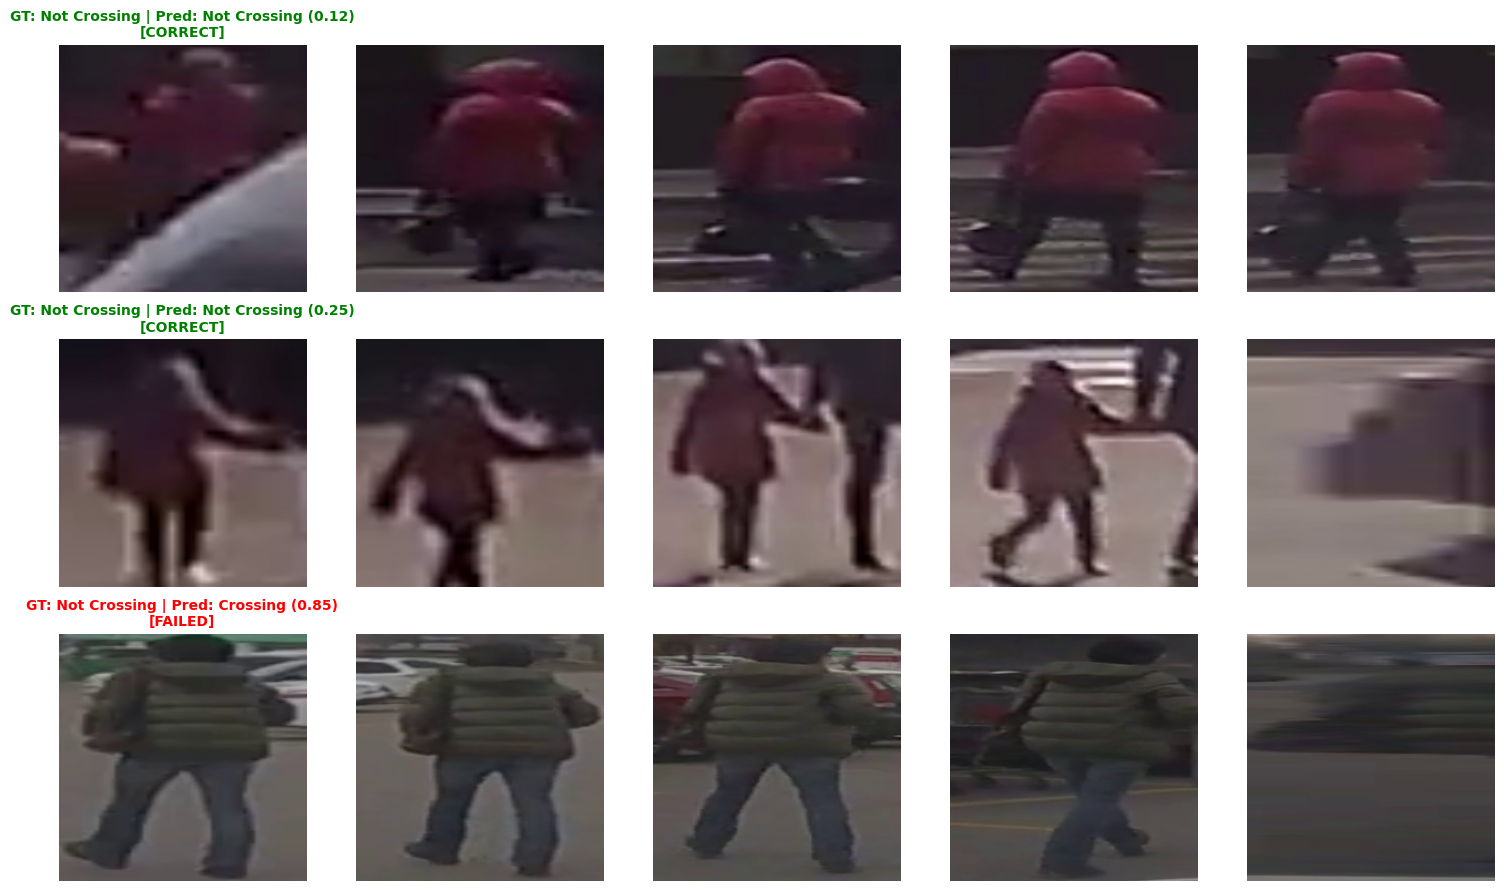

In [35]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# Standalone Visualization Helper
# --------------------------------------------------------------------------
def visualize_qualitative_samples_from_checkpoint(config_or_dir, num_samples=3, random_sample=True):
    """
    Loads the saved best model checkpoint and visualizes qualitative predictions
    across 5 key temporal frames per sequence from the test set.

    Args:
        config_or_dir: Directory path string OR TrainConfig object.
        num_samples: Number of video sequences to plot.
        random_sample: If True, randomly picks samples across test set rather than the first N.
    """
    # 1. Resolve run output path
    if isinstance(config_or_dir, str):
        output_dir = config_or_dir
    elif hasattr(config_or_dir, "output_dir"):
        output_dir = config_or_dir.output_dir
    else:
        raise ValueError("Argument must be a config instance or directory path string.")

    ckpt_path = os.path.join(output_dir, "best_model.pth")
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"No checkpoint found at '{ckpt_path}'. Run training first!")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 2. Extract hyperparameters directly from stored checkpoint state
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    ckpt_config = checkpoint.get("config", {})

    data_dir = ckpt_config.get("data_dir", "/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Processed_JAAD_Dataset_Images")
    img_size = ckpt_config.get("img_size", 224)
    seq_len = ckpt_config.get("seq_len", 10)
    hidden_dim = ckpt_config.get("hidden_dim", 128)
    classifier_dropout = ckpt_config.get("classifier_dropout", 0.5)

    # 3. Instantiate test dataset & model independently
    test_ds = JAADImageDataset(
        data_dir, "test", train=False, img_size=img_size, seq_len=seq_len
    )

    model = CrossingMobileNetGRU(
        hidden_dim=hidden_dim,
        classifier_dropout=classifier_dropout
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    # 4. Select sequence indices to visualize
    total_test_samples = len(test_ds)
    num_samples = min(num_samples, total_test_samples)

    if random_sample:
        sample_indices = random.sample(range(total_test_samples), num_samples)
    else:
        sample_indices = list(range(num_samples))

    # 5. Build visualization plot
    fig, axes = plt.subplots(num_samples, 5, figsize=(15, 3 * num_samples))

    with torch.no_grad():
        for i, idx in enumerate(sample_indices):
            seq_tensor, label = test_ds[idx]
            input_tensor = seq_tensor.unsqueeze(0).to(device)

            # Forward pass inference
            logit = model(input_tensor)
            prob = torch.sigmoid(logit).item()
            pred = 1 if prob >= 0.5 else 0
            label_val = int(label.item() if isinstance(label, torch.Tensor) else label)

            # Sample 5 frame indexes dynamically based on seq_len
            frame_indices = np.linspace(0, seq_len - 1, 5).astype(int)

            for j, f_idx in enumerate(frame_indices):
                # Inverse transform ImageNet normalization for plotting
                img = seq_tensor[f_idx].cpu().numpy().transpose(1, 2, 0)
                img = np.array(IMAGENET_STD) * img + np.array(IMAGENET_MEAN)
                img = np.clip(img, 0.0, 1.0)

                # Ensure 2D indexing safe for single row plots (num_samples=1)
                ax = axes[j] if num_samples == 1 else axes[i, j]
                ax.imshow(img)
                ax.axis('off')

                if j == 0:
                    status = "CORRECT" if pred == label_val else "FAILED"
                    status_color = 'green' if pred == label_val else 'red'
                    class_map = {0: "Not Crossing", 1: "Crossing"}

                    title_text = (
                        f"GT: {class_map.get(label_val, label_val)} | "
                        f"Pred: {class_map.get(pred, pred)} ({prob:.2f})\n"
                        f"[{status}]"
                    )
                    ax.set_title(title_text, fontsize=10, fontweight='bold', color=status_color)

    plt.tight_layout()
    plt.show()


# --------------------------------------------------------------------------
# Execution
# --------------------------------------------------------------------------
run_dir = "/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Runs/run_mobilenet_gru"
visualize_qualitative_samples_from_checkpoint(run_dir, num_samples=3, random_sample=True)

---
## 10. Model Evaluation on Unseen Held-Out Data (`new_data`)

To test true generalization performance under real-world autonomous driving conditions, the best checkpoint is evaluated on the **20 held-out videos** (`new_data`) that were completely excluded from model selection and hyperparameter tuning.

In [4]:
import os
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.models as models
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
)

# --------------------------------------------------------------------------
# Constants
# --------------------------------------------------------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# --------------------------------------------------------------------------
# 1. Dataset Definition
# --------------------------------------------------------------------------
class JAADImageDataset(Dataset):
    def __init__(self, data_dir: str, split: str, train: bool = False, img_size: int = 224, seq_len: int = 10):
        self.split_dir = os.path.join(data_dir, split)
        self.train = train
        self.img_size = img_size
        self.seq_len = seq_len
        self.samples = []

        if not os.path.exists(self.split_dir):
            raise ValueError(f"Split directory '{self.split_dir}' does not exist.")

        for label_str in ['crossing', 'not_crossing']:
            label_val = 1.0 if label_str == 'crossing' else 0.0
            class_dir = os.path.join(self.split_dir, label_str)

            if not os.path.exists(class_dir):
                continue

            for seq_folder in os.listdir(class_dir):
                seq_path = os.path.join(class_dir, seq_folder)
                if os.path.isdir(seq_path):
                    frames = sorted([f for f in os.listdir(seq_path) if f.endswith(('.jpg', '.png', '.jpeg'))])

                    if len(frames) == 0:
                        continue

                    if len(frames) >= self.seq_len:
                        indices = np.linspace(0, len(frames) - 1, self.seq_len).astype(int)
                        selected_frames = [frames[i] for i in indices]
                    else:
                        selected_frames = frames + [frames[-1]] * (self.seq_len - len(frames))

                    frame_paths = [os.path.join(seq_path, f) for f in selected_frames]
                    self.samples.append({
                        "frame_paths": frame_paths,
                        "label": label_val
                    })

        if len(self.samples) == 0:
            raise ValueError(f"No valid sequences found in {self.split_dir}")

    def __len__(self):
        return len(self.samples)

    def labels(self):
        return [s["label"] for s in self.samples]

    def __getitem__(self, idx):
        sample = self.samples[idx]
        frame_paths = sample["frame_paths"]
        label = sample["label"]

        do_flip = self.train and random.random() < 0.5
        rot_angle = random.uniform(-10.0, 10.0) if self.train else 0.0
        brightness = random.uniform(0.8, 1.2) if self.train else 1.0
        contrast = random.uniform(0.8, 1.2) if self.train else 1.0
        saturation = random.uniform(0.8, 1.2) if self.train else 1.0

        frames = []
        for path in frame_paths:
            img_bgr = cv2.imread(path)
            if img_bgr is None:
                img_bgr = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0

            if tensor.shape[1] != self.img_size or tensor.shape[2] != self.img_size:
                tensor = TF.resize(tensor, [self.img_size, self.img_size], antialias=True)

            if self.train:
                if do_flip:
                    tensor = TF.hflip(tensor)
                if abs(rot_angle) > 0.1:
                    tensor = TF.rotate(tensor, angle=rot_angle)
                tensor = TF.adjust_brightness(tensor, brightness)
                tensor = TF.adjust_contrast(tensor, contrast)
                tensor = TF.adjust_saturation(tensor, saturation)

            tensor = TF.normalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
            frames.append(tensor)

        sequence_tensor = torch.stack(frames, dim=0)  # (T, 3, H, W)
        return sequence_tensor, torch.tensor(label)


# --------------------------------------------------------------------------
# 2. Architecture Definitions
# --------------------------------------------------------------------------
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, max(hidden_dim // 2, 1)),
            nn.Tanh(),
            nn.Linear(max(hidden_dim // 2, 1), 1),
        )

    def forward(self, rnn_out):
        scores = self.attn(rnn_out)               # (N, T, 1)
        weights = torch.softmax(scores, dim=1)     # (N, T, 1)
        context = (rnn_out * weights).sum(dim=1)  # (N, hidden_dim)
        return context


class CrossingMobileNetGRU(nn.Module):
    def __init__(self, hidden_dim=128, classifier_dropout=0.5):
        super().__init__()
        mobilenet = models.mobilenet_v3_small(weights=None)
        in_features = mobilenet.classifier[0].in_features
        mobilenet.classifier = nn.Identity()
        self.backbone = mobilenet

        self.gru = nn.GRU(
            input_size=in_features,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        rnn_out_dim = hidden_dim * 2

        self.attention = TemporalAttention(rnn_out_dim)

        self.classifier = nn.Sequential(
            nn.Linear(rnn_out_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(classifier_dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        n, t, c, h, w = x.shape
        x = x.view(n * t, c, h, w)
        feats = self.backbone(x)            # (N*T, in_features)
        feats = feats.view(n, t, -1)        # (N, T, in_features)

        rnn_out, _ = self.gru(feats)        # (N, T, hidden_dim * 2)
        context = self.attention(rnn_out)   # (N, hidden_dim * 2)

        logits = self.classifier(context)   # (N, 1)
        return logits


# --------------------------------------------------------------------------
# 3. Metric Calculations & Forward Pass Loop
# --------------------------------------------------------------------------
def compute_metrics(y_true, y_probs, threshold=0.5):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    preds = (y_probs >= threshold).astype(int)

    acc = accuracy_score(y_true, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, preds, average="binary", zero_division=0
    )
    try:
        auc = roc_auc_score(y_true, y_probs)
    except ValueError:
        auc = float("nan")
    try:
        pr_auc = average_precision_score(y_true, y_probs)
    except ValueError:
        pr_auc = float("nan")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": auc,
        "pr_auc": pr_auc,
    }


def run_evaluation(model, loader, device, criterion, use_amp=True):
    model.eval()
    total_loss, n_samples = 0.0, 0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).float().unsqueeze(1)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
                logits = model(inputs)
                loss = criterion(logits, labels)

            total_loss += loss.item() * inputs.size(0)
            n_samples += inputs.size(0)
            probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.detach().cpu().numpy().flatten().tolist())

    avg_loss = total_loss / max(n_samples, 1)
    return avg_loss, all_labels, all_probs


# --------------------------------------------------------------------------
# 4. Evaluation Function for New / Unseen Data
# --------------------------------------------------------------------------
def evaluate_model_on_new_data(output_dir, split_name="new_data"):
    """
    Evaluates the trained model state against completely unseen dataset splits (e.g. 'new_data' or 'test').
    Prints all relevant rubric metrics: Loss, Accuracy, Precision, Recall, F1, ROC-AUC, and Confusion Matrix.
    """
    ckpt_path = os.path.join(output_dir, "best_model.pth")
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"No checkpoint found at '{ckpt_path}'. Verify training output directory.")

    print("\n" + "="*60)
    print(f"🧪 EVALUATING MODEL ON HELD-OUT UNSEEN DATA ('{split_name}')")
    print("="*60)

    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    ckpt_config = checkpoint.get("config", {})

    data_dir = ckpt_config.get("data_dir", "/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Processed_JAAD_Dataset_Images")
    img_size = ckpt_config.get("img_size", 224)
    seq_len = ckpt_config.get("seq_len", 10)
    batch_size = ckpt_config.get("batch_size", 16)
    num_workers = ckpt_config.get("num_workers", 2)
    hidden_dim = ckpt_config.get("hidden_dim", 128)
    classifier_dropout = ckpt_config.get("classifier_dropout", 0.5)
    use_amp = ckpt_config.get("use_amp", True)

    # Initialize New Data Loader
    eval_ds = JAADImageDataset(
        data_dir, split=split_name, train=False, img_size=img_size, seq_len=seq_len
    )
    eval_loader = DataLoader(
        eval_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=use_cuda
    )

    # Instantiate and load trained model
    model = CrossingMobileNetGRU(
        hidden_dim=hidden_dim,
        classifier_dropout=classifier_dropout
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])

    criterion = nn.BCEWithLogitsLoss()

    # Perform evaluation
    eval_loss, eval_labels, eval_probs = run_evaluation(
        model, eval_loader, device, criterion, use_amp=use_amp
    )

    eval_metrics = compute_metrics(eval_labels, eval_probs, threshold=0.5)
    preds = (np.array(eval_probs) >= 0.5).astype(int)

    # Output detailed Rubric Results
    print(f"Total Evaluated Sequences: {len(eval_ds)}")
    print(f"Loaded Model Checkpoint   : Epoch {checkpoint.get('epoch', 'N/A')}")
    print(f"Evaluation Loss          : {eval_loss:.4f}")
    print(f"Accuracy                 : {eval_metrics['accuracy'] * 100:.2f}%")
    print(f"Precision                : {eval_metrics['precision']:.4f}")
    print(f"Recall                   : {eval_metrics['recall']:.4f}")
    print(f"F1-Score                 : {eval_metrics['f1']:.4f}")
    print(f"ROC-AUC                  : {eval_metrics['roc_auc']:.4f}")
    print(f"PR-AUC                   : {eval_metrics['pr_auc']:.4f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(eval_labels, preds)
    print(f"TN: {cm[0,0]} | FP: {cm[0,1]}")
    print(f"FN: {cm[1,0]} | TP: {cm[1,1]}")

    print("\nDetailed Classification Report:")
    print(classification_report(
        eval_labels, preds, target_names=["not_crossing", "crossing"], zero_division=0
    ))
    print("="*60)

    return eval_metrics


# --------------------------------------------------------------------------
# Execution
# --------------------------------------------------------------------------
if __name__ == "__main__":
    run_dir = "/content/drive/MyDrive/Colab Notebooks/APS360/Final Project/Runs/run_mobilenet_gru"

    # Passes 'new_data' directory name (or 'test' if your unseen split is named test)
    results = evaluate_model_on_new_data(output_dir=run_dir, split_name="new_data")


🧪 EVALUATING MODEL ON HELD-OUT UNSEEN DATA ('new_data')
Total Evaluated Sequences: 20
Loaded Model Checkpoint   : Epoch 24
Evaluation Loss          : 0.4587
Accuracy                 : 80.00%
Precision                : 0.6667
Recall                   : 0.4000
F1-Score                 : 0.5000
ROC-AUC                  : 0.8533
PR-AUC                   : 0.6833

Confusion Matrix:
TN: 14 | FP: 1
FN: 3 | TP: 2

Detailed Classification Report:
              precision    recall  f1-score   support

not_crossing       0.82      0.93      0.88        15
    crossing       0.67      0.40      0.50         5

    accuracy                           0.80        20
   macro avg       0.75      0.67      0.69        20
weighted avg       0.78      0.80      0.78        20

